# Class 15: For loops and writing functions

In this notebook we will continuing learning some of the fundamentals of Python, namely using for loops, conditional statements and writing functions. This material will be useful for analyzing data, and more generally for any programming you do in the future. 

In [1]:
import YData

# YData.download.download_class_code(15)       
# YData.download.download_class_code(15, TRUE) # get the code with the answers 
# YData.download.download_homework(6)  # download the homework 

YData.download.download_data("ne_110m_admin_0_countries.zip")
YData.download.download_data("States_shapefile.geojson")
YData.download.download_data("state_demographics.csv")
YData.download_data('daily_bike_totals.csv')
YData.download_image("powers.jpg")

The file `ne_110m_admin_0_countries.zip` already exists.
If you would like to download a new copy of the file, please rename the existing copy of the file.
The file `States_shapefile.geojson` already exists.
If you would like to download a new copy of the file, please rename the existing copy of the file.
The file `state_demographics.csv` already exists.
If you would like to download a new copy of the file, please rename the existing copy of the file.
The file `daily_bike_totals.csv` already exists.
If you would like to download a new copy of the file, please rename the existing copy of the file.
The file `powers.jpg` already exists.
If you would like to download a new copy of the file, please rename the existing copy of the file.


In [2]:
## If you are using Google Colabs, you should install the YData packages and mount the your google drive by uncommenting and running the code below.

# !pip install https://github.com/yuejiechi/YData_package/tarball/master
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import plotly.express as px

## 1. Choropleth maps

In choropleth maps, predefined regions are filled in with colors based values of interest. 

Let's fit a choropleth map examining which states in the USA are growing in terms of people having lots of childern. 

Any thoughts on which state this might be? 

To start, let's load a map with the outlines of the states in the USA, and load demographic data.

In [4]:
state_map = gpd.read_file("States_shapefile.geojson")

print(state_map.crs)

state_map.head(3)

EPSG:4326


,FID,Program,State_Code,State_Name,Flowing_St,FID_1,geometry
0,1,PERMIT TRACKING,AL,ALABAMA,F,919,"POLYGON ((-85.07007 31.9807, -85.11515 31.9074..."
1,2,,AK,ALASKA,N,920,"MULTIPOLYGON (((-161.33379 58.73325, -161.3824..."
2,3,AZURITE,AZ,ARIZONA,F,921,"POLYGON ((-114.52063 33.02771, -114.55909 33.0..."


In [5]:
# load demographic data on the states

state_demographics = pd.read_csv("state_demographics.csv")
state_demographics.head(3)

,State,under_5,over_64,bachelors_degree,total
0,Alabama,295811.997,741954.681,1095959.202,4849377
1,Alaska,54518.168,69252.808,202601.300,736732
2,Arizona,430814.976,1070305.956,1810769.196,6731484


In [6]:
# In order to join the DataFrames, we need to make sure the states have the same capitalization

state_demographics2 = state_demographics.copy()
state_demographics2["State"] = state_demographics["State"].apply(str.upper)

state_demographics2.head()

,State,under_5,over_64,bachelors_degree,total
0,ALABAMA,295811.997,741954.681,1.095959e+06,4849377
1,ALASKA,54518.168,69252.808,2.026013e+05,736732
2,ARIZONA,430814.976,1070305.956,1.810769e+06,6731484
3,ARKANSAS,192813.985,465719.933,5.962402e+05,2966369
4,CALIFORNIA,2522162.500,5005522.500,1.191237e+07,38802500


In [7]:
# Join the demographic information on to the the USA map

state_map_demo = state_map.merge(state_demographics2, 
                                 left_on = "State_Name", right_on = "State")
state_map_demo.head(3)

,FID,Program,State_Code,State_Name,Flowing_St,FID_1,geometry,State,under_5,over_64,bachelors_degree,total
0,1,PERMIT TRACKING,AL,ALABAMA,F,919,"POLYGON ((-85.07007 31.9807, -85.11515 31.9074...",ALABAMA,295811.997,741954.681,1095959.202,4849377
1,2,,AK,ALASKA,N,920,"MULTIPOLYGON (((-161.33379 58.73325, -161.3824...",ALASKA,54518.168,69252.808,202601.300,736732
2,3,AZURITE,AZ,ARIZONA,F,921,"POLYGON ((-114.52063 33.02771, -114.55909 33.0...",ARIZONA,430814.976,1070305.956,1810769.196,6731484


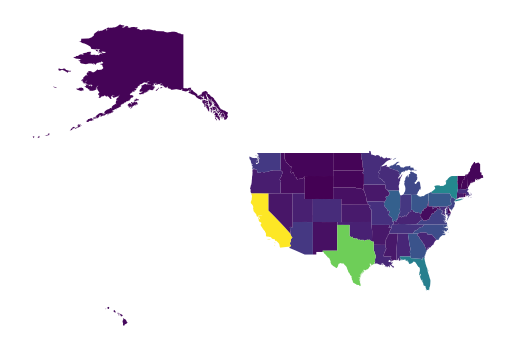

In [8]:
# Let's plot the map 

ax = state_map_demo.plot(column = "under_5", cmap='viridis');

ax.set_axis_off();

Is there anything [wrong with this map](https://xkcd.com/1138/)? 

In [9]:
# Let's look at the proportion of people under the age of 5

state_map_demo2 = state_map_demo.copy()

state_map_demo2["percent_under_5"] = 100 * state_map_demo["under_5"]/state_map_demo["total"]

state_map_demo2.head(3)


,FID,Program,State_Code,State_Name,Flowing_St,FID_1,geometry,State,under_5,over_64,bachelors_degree,total,percent_under_5
0,1,PERMIT TRACKING,AL,ALABAMA,F,919,"POLYGON ((-85.07007 31.9807, -85.11515 31.9074...",ALABAMA,295811.997,741954.681,1095959.202,4849377,6.1
1,2,,AK,ALASKA,N,920,"MULTIPOLYGON (((-161.33379 58.73325, -161.3824...",ALASKA,54518.168,69252.808,202601.300,736732,7.4
2,3,AZURITE,AZ,ARIZONA,F,921,"POLYGON ((-114.52063 33.02771, -114.55909 33.0...",ARIZONA,430814.976,1070305.956,1810769.196,6731484,6.4


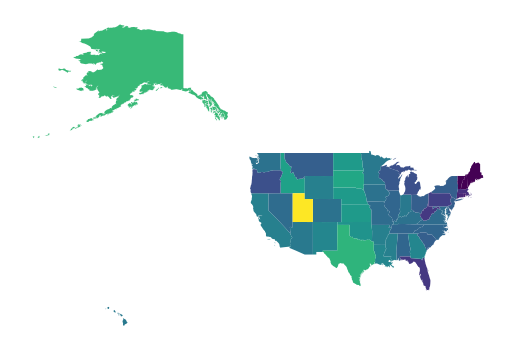

In [10]:
# Let's plot the new map

ax = state_map_demo2.plot(column = "percent_under_5", cmap='viridis');

ax.set_axis_off();

## 2. Loops

Loops allow us to repeat a process many times. They are particularly useful in conjuction with lists to process and store multiple values. 


In [40]:
# Loop over items in a list
a_list = ["first", "second", "third", "forth"]


for item in a_list:
    print(item)


first
second
third
forth


In [12]:
# Loop over numbers using the range() function

for i in range(10):
    print(i)


0
1
2
3
4
5
6
7
8
9


In [13]:
# Can you print the squares of the numbers from 1 to 6? 

for i in range(1, 7): 
    print(i**2)

1
4
9
16
25
36


We can use a loop to build up values in a list...

In [14]:
# Create a list that has the squares of the numbers 1 to 6
# hint: the .append() method will be useful

my_squares = []

for i in range(1, 7):
    
    my_squares.append(i**2)


my_squares


[1, 4, 9, 16, 25, 36]

### Exercise 1

Can you use loops to sum the numbers 1 to 10? 

Or, to use mathematical notation, can you compute $\sum_{i=1}^{10} i$ ?


In [15]:
# Sum numbers from 1 to 10
my_sum = 0

for i in range(1, 11):
    my_sum = my_sum + i

my_sum

55

### Enumerate

We can use enumerate(my_list) to get both values from a list and sequential index numbers.


In [16]:
# We can use enumerate(my_list) to get both values from a list 
# and sequential index numbers

a_list = ["first", "second", "third", "forth"]

for i, curr_val in enumerate(a_list):
    print(str(i) + " " + curr_val)


0 first
1 second
2 third
3 forth


### zip function

We can use `zip(list_1, list_2)` to get values from two lists in a for loop. 


In [43]:
list_1 = ["a", "b", "c"]
list_2 = ["x", "y", "z"]


for item1, item2 in zip(list_1, list_2):
    print(item1, item2)


zip

### Exercise 2

The code below extracts two lists that have the the high and low temperatures from 2014 in NYC. 

Please use for loops to create a list called `temp_range` that has the temperature range (high - low temperature) for each day.

There are a few ways to do this, so see if you can come up with a solution that works. Try to do this without using numpy, and once you have a solution, see if you can get the same result using numpy. 



In [18]:
import pandas as pd
import matplotlib.pyplot as plt

bikes = pd.read_csv("daily_bike_totals.csv", parse_dates = [0])
bikes_2014 = bikes.query("date > '2013-12-31'").query("date < '2015-01-01'")

max_temps = bikes_2014["max_temperature"].to_list()
min_temps = bikes_2014["min_temperature"].to_list()

print(max_temps[0:5])
print(min_temps[0:5])

[33.08, 33.08, 18.14, 29.12, 39.92]
[24.26, 18.14, 9.14, 8.24, 27.14]


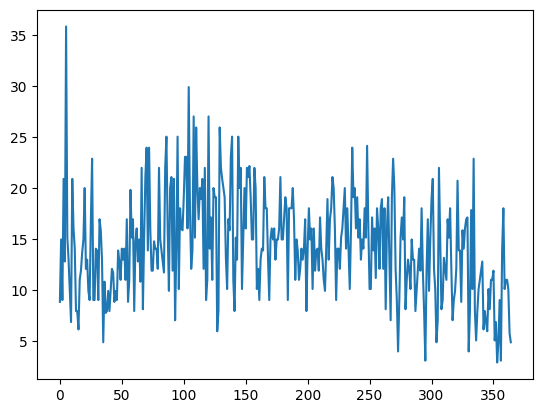

In [19]:
# Create a list called "temp_range" that has the temperature range for each day in 2014...

# Start with an empty list
temp_range = [];


# Use a for loop to add the temperature range for each day
for i in range(len(max_temps)):

    curr_max = max_temps[i]
    curr_min = min_temps[i]
    temp_range.append(curr_max - curr_min)



# Plot the range of temperatures
plt.plot(temp_range);


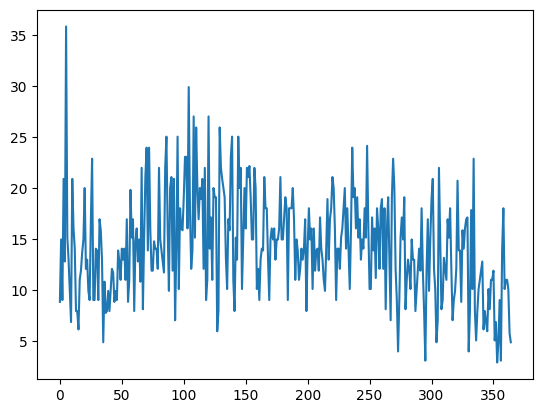

In [20]:
# Alternative solution using the zip function...

# Start with an empty list
temp_range2 = [];


# Use a for loop to add the temperature range for each day
for curr_max, curr_min in zip(max_temps, min_temps):

    temp_range2.append(curr_max - curr_min)



# Plot the range of temperatures
plt.plot(temp_range2);


In [21]:
# Can you do the same calculation using numpy arrays?  
# Which is easier? 
import numpy as np

temp_range_array = np.array(max_temps) - np.array(min_temps)


# checking they are the same
np.sum(temp_range_array == np.array(temp_range))


np.int64(365)

## 3a. Review of comparisons

Let's do a very quick review of mathematical and string comparisons in Python.

In [22]:
# Basic math comparison
3 > 1

True

In [23]:
# Checking the type of a basic math comparison
type(3 > 1)

bool

In [24]:
# We use == to compare whether two items are equal (not 3 = 3)
3 == 3

True

In [25]:
# We can use the `and` keyword to combine multiple logical statements 
n1 = 20
n2 = 2

n1 > 10 and n2 > 5

False

In [26]:
# We can also use the `or` keyword to combine multiple logical statements 
n1 > 10 or n2 > 5

True

In [27]:
# We can also compare strings
"my string" == "my string"

True

In [28]:
# Stings compare alphabetically
"cats" < "dogs"

True

In [29]:
# Shorter words occur earlier than longer words that have matching letters
"cat" < "catastrophe"

True

## 3b. Conditional Statements 

Conditional statements allow use to excecute particular pieces of code when certain conditions are met; i.e., they execute a piece of code when a Boolean value is True. 

Let's explore!

In [30]:
num_semesters = 7

if num_semesters <= 0:
    print('Not a valid input')
elif num_semesters <= 2:
    print('First Year')
elif num_semesters <= 4:
    print('Sophomore')
elif num_semesters <= 6:
    print('Junior')
elif num_semesters <= 8:
    print('Senior')
else:
    print("NA")


Senior


In [31]:
# Let's look at a conditional statement in a loop

for num_semesters in range(10):
    
    print(num_semesters)

    if num_semesters <= 0:
        print('Not a valid input')
    elif num_semesters <= 2:
        print('First Year')
    elif num_semesters <= 4:
        print('Sophomore')
    elif num_semesters <= 6:
        print('Junior')
    elif num_semesters <= 8:
        print('Senior')
    else:
        print("NA")


0
Not a valid input
1
First Year
2
First Year
3
Sophomore
4
Sophomore
5
Junior
6
Junior
7
Senior
8
Senior
9
NA


In [32]:
%%capture

# You can run this code to covert this Jupyter notebook into a pdf
!quarto render class_15_answers.ipynb --cache-refresh --to pdf 